# 9.2 Space-Time Weights and Global Analysis

**Part:** 9 — Spatio-Temporal Analysis (Chapter 9.2 of 7)

**Dataset:** `data_1998_2010_long_lbc.csv` (year-by-year Moran's I); `crime_data_2018.csv` (a hand-built Knox test)

**Focus:** year-by-year Moran's I and `Moran_Diff` (library-supported); Kronecker space-time weights and the Knox test (hand-built; not in the library)

**Library:** `spatialstats.esda` for Sections 3-4; everything in Section 5 is built by hand

***

## Table of Contents

1.. [Overview](#1.-Overview)
2.. [Python Setup](#2.-Python-Setup)
3.. [Year-by-Year Moran's I](#3.-Year-by-Year-Moran's-I)
4.. [Moran_Diff: Is the Change Itself Clustered?](#4.-Moran_Diff:-Is-the-Change-Itself-Clustered?)
5.. [The Knox Test for Space-Time Interaction (Hand-Built)](#5.-The-Knox-Test-for-Space-Time-Interaction-(Hand-Built))
6.. [What a Real Kronecker Space-Time Weights Matrix Would Add](#6.-What-a-Real-Kronecker-Space-Time-Weights-Matrix-Would-Add)
7.. [Summary and Conclusions](#7.-Summary-and-Conclusions)
8.. [Resources](#8.-Resources)

***
## 1. Overview

This chapter runs the two genuinely library-supported space-time analyses this Part has (Sections 3-4), then
builds, entirely by hand, one further classical space-time method the outline calls for but
`spatialstats.spacetime` does not implement: the Knox test for event interaction.

| Step | What we do | Library status |
|------|------------|-----------------|
| Year-by-year Moran's I | 15 separate `esda.Moran` calls, one fixed weights matrix | ✅ Library-supported |
| `Moran_Diff` | Is the *change* in `RATE` between two years itself spatially clustered? | ✅ Library-supported |
| Knox test | Are crime incidents close in space also close in time, more than chance? | 🔨 Hand-built, not in the library |
| Kronecker space-time weights | What a real implementation would need | 🔲 Explained, not built |

***
## 2. Python Setup

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "data").is_dir():
            return p
    raise FileNotFoundError("Run this notebook from inside the PySpatialStats repository.")


ROOT = find_repo_root()
DATA = ROOT / "data"
try:
    import spatialstats
except ImportError:
    sys.path.insert(0, str(ROOT))
    import spatialstats

from spatialstats.esda import Moran, Moran_Diff
from spatialstats.weights import KNN

plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 100, "font.size": 10, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
})
COLORS = {"blue": "#2b6cb0", "red": "#c0392b", "green": "#2f855a", "orange": "#dd6b20",
          "grey": "#718096", "purple": "#6b46c1", "teal": "#2c7a7b"}
print(f"spatialstats : version {spatialstats.__version__}")

spatialstats : version 0.2.0


***
## 3. Year-by-Year Moran's I

The panel is balanced (Chapter 9.1) and every year shares the same 3,107 counties in the same order, so a
**single spatial weights matrix**, built once from any one year's coordinates, applies unchanged to every year —
counties do not move.

In [2]:
panel = pd.read_csv(DATA / "data_1998_2010_long_lbc.csv")
reference = panel[panel["Year"] == 1998].sort_values("FIPS").reset_index(drop=True)
coords = reference[["X", "Y"]].to_numpy()
w = KNN(coords, k=6)

years = sorted(panel["Year"].unique())
moran_by_year = []
for year in years:
    d = panel[panel["Year"] == year].sort_values("FIPS").reset_index(drop=True)
    assert (d["FIPS"].to_numpy() == reference["FIPS"].to_numpy()).all(), "county order must match the weights matrix"
    m = Moran(d["RATE"].to_numpy(), w, permutations=499, seed=1)
    moran_by_year.append({"year": year, "I": m.I, "p_value": m.p_value})

moran_df = pd.DataFrame(moran_by_year)
moran_df

,year,I,p_value
0,1998,0.732525,0.002
1,1999,0.730552,0.002
2,2000,0.729447,0.002
3,2001,0.726398,0.002
4,2002,0.723535,0.002
5,2003,0.723010,0.002
6,2004,0.720286,0.002
7,2005,0.719953,0.002
8,2006,0.717638,0.002
9,2007,0.718024,0.002


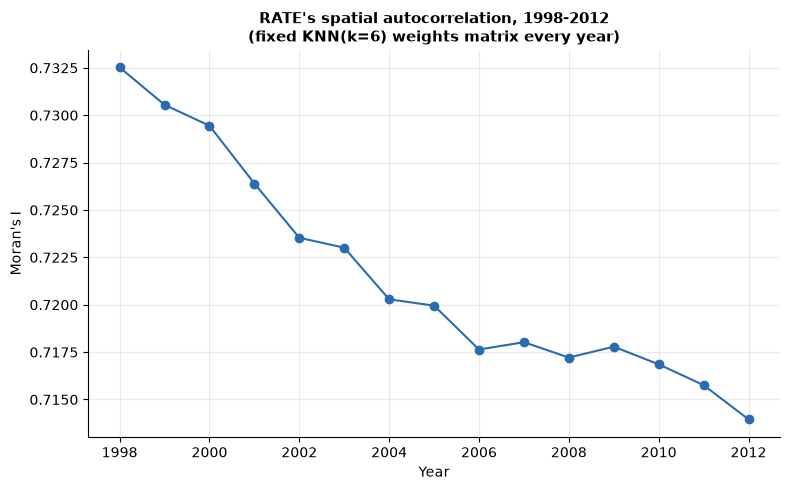

1998: I=0.7325   2012: I=0.7140   change: -0.0186


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(moran_df["year"], moran_df["I"], "o-", color=COLORS["blue"])
ax.set_xlabel("Year"); ax.set_ylabel("Moran's I")
ax.set_title("RATE's spatial autocorrelation, 1998-2012\n(fixed KNN(k=6) weights matrix every year)")
plt.tight_layout()
plt.savefig("moran_by_year.png", dpi=100, bbox_inches="tight")
plt.show()

print(f"1998: I={moran_df.iloc[0]['I']:.4f}   2012: I={moran_df.iloc[-1]['I']:.4f}   "
     f"change: {moran_df.iloc[-1]['I'] - moran_df.iloc[0]['I']:+.4f}")

`RATE` is strongly, significantly spatially autocorrelated in **every single year** ($p<0.01$ throughout) — but
the *strength* of that clustering **declines gradually and almost monotonically** across the 15-year span, from
0.733 in 1998 to 0.714 in 2012. This is exactly a case where treating the cube as "the same spatial pattern,
just repeated 15 times" would miss something real: the underlying geography of clustering is not static, even
though it never disappears.

***
## 4. Moran_Diff: Is the Change Itself Clustered?

Chapter 9.1 established that `Moran_Diff` computes the Moran's I of the **difference** $y_t - y_{t0}$, not a
test of whether $I(t)$ differs from $I(t_0)$. This answers a genuinely different, useful question: do counties
that *increased* tend to sit near other counties that also increased (organized, spatially clustered change),
or is the year-to-year change itself spatially patternless noise superimposed on a spatially structured level?

Moran's I of (RATE_2012 - RATE_1998): 0.6815   p=0.0010
change range: -28.24 to 21.72   mean: -7.34


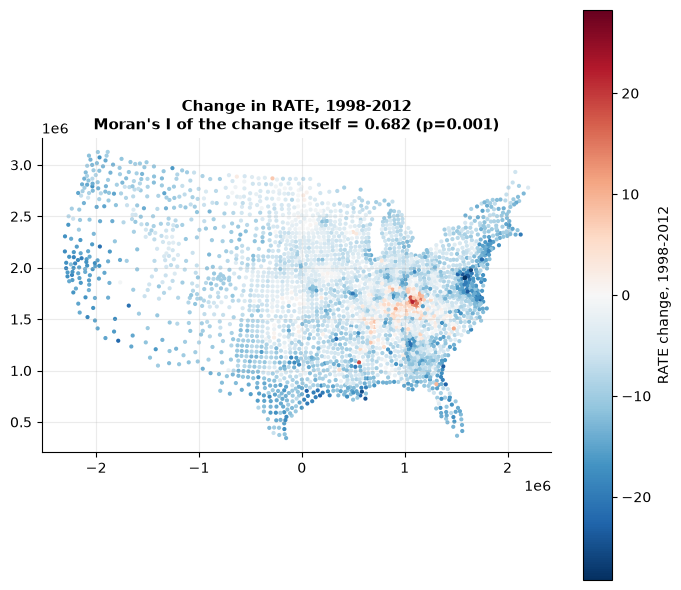

In [4]:
d1998 = panel[panel["Year"] == 1998].sort_values("FIPS").reset_index(drop=True)
d2012 = panel[panel["Year"] == 2012].sort_values("FIPS").reset_index(drop=True)
assert (d1998["FIPS"].to_numpy() == d2012["FIPS"].to_numpy()).all()

diff_result = Moran_Diff(d2012["RATE"].to_numpy(), d1998["RATE"].to_numpy(), w, permutations=999, seed=1)
print(f"Moran's I of (RATE_2012 - RATE_1998): {diff_result.I:.4f}   p={diff_result.p_value:.4f}")

change = d2012["RATE"].to_numpy() - d1998["RATE"].to_numpy()
print(f"change range: {change.min():.2f} to {change.max():.2f}   mean: {change.mean():.2f}")

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(d2012["X"], d2012["Y"], c=change, cmap="RdBu_r", s=4,
                vmin=-np.abs(change).max(), vmax=np.abs(change).max())
plt.colorbar(sc, ax=ax, label="RATE change, 1998-2012")
ax.set_title(f"Change in RATE, 1998-2012\nMoran's I of the change itself = {diff_result.I:.3f} (p={diff_result.p_value:.3f})")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("moran_diff_map.png", dpi=100, bbox_inches="tight")
plt.show()

**Yes — the change itself is significantly, positively spatially clustered.** Counties that saw `RATE` rise over
the 15 years are not scattered at random; they cluster near other counties that also rose, and the same is true
of counties that fell. This is a materially different and complementary finding to Section 3's declining-$I(t)$
curve: the *level* of clustering is gently weakening, but *where the change happened* is itself geographically
organized — a real, regional pattern in who got better and who got worse, worth investigating substantively
(e.g. against `SMOKING`, `POVERTY`, or the pollution covariates in the same file) rather than reading purely as
noise.

***
## 5. The Knox Test for Space-Time Interaction (Hand-Built)

**Not in this library.** The Knox test asks a classic space-time epidemiology question: do event pairs that are
close in space tend to *also* be close in time, more often than chance alone would produce? For a chosen spatial
threshold $D_s$ and temporal threshold $D_t$, the test statistic is simply the count of pairs satisfying both:
$$
X = \sum_{i<j} \mathbb{1}\!\left[d_s(i,j) < D_s\right] \cdot \mathbb{1}\!\left[d_t(i,j) < D_t\right]
$$
Its null distribution (no space-time interaction — spatial and temporal proximity are independent) is built by
**permutation**: shuffle the time labels across the fixed locations, recompute $X$, repeat, and compare the
observed $X$ to that null distribution.

In [5]:
crime = pd.read_csv(DATA / "crime_data_2018.csv")
crime["date_incid"] = pd.to_datetime(crime["date_incid"])
crime["day_of_year"] = crime["date_incid"].dt.dayofyear

crime_gdf = gpd.GeoDataFrame(crime, geometry=gpd.points_from_xy(crime["long"], crime["lat"]),
                             crs="EPSG:4326").to_crs("EPSG:32617")   # Chapter 9.1's verified fix
coords_crime = np.c_[crime_gdf.geometry.x, crime_gdf.geometry.y]
doy = crime["day_of_year"].to_numpy()

D_S, D_T = 100.0, 1   # metres, days
tree = cKDTree(coords_crime)
spatial_pairs = np.array(list(tree.query_pairs(D_S)))
print(f"{len(spatial_pairs):,} pairs within {D_S:.0f} m of each other (out of "
     f"{len(coords_crime)*(len(coords_crime)-1)//2:,} possible pairs)")


def knox_statistic(day_labels, pairs, d_t):
    dt = np.abs(day_labels[pairs[:, 0]] - day_labels[pairs[:, 1]])
    return int((dt <= d_t).sum())


observed = knox_statistic(doy, spatial_pairs, D_T)
print(f"observed space-time-close pairs (within {D_S:.0f} m AND {D_T} day): {observed:,}")

111,135 pairs within 100 m of each other (out of 98,007,000 possible pairs)
observed space-time-close pairs (within 100 m AND 1 day): 1,278


null distribution: mean=932.9, sd=30.6
observed=1278   z=11.27   p=0.0000 (999 permutations)


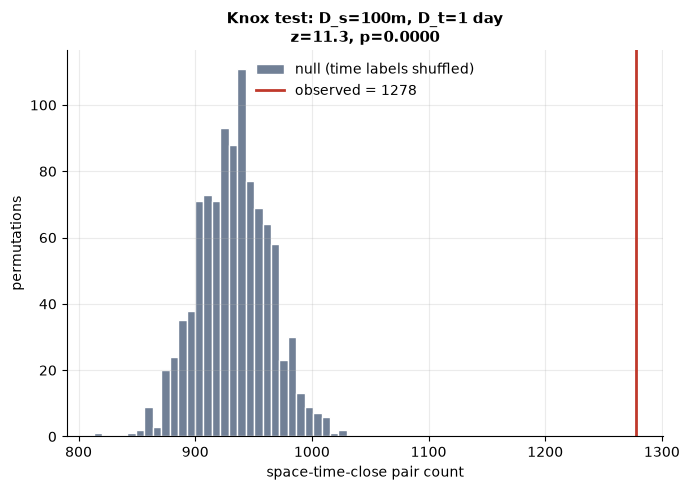

In [6]:
rng = np.random.default_rng(1)
n_perm = 999
null_counts = np.empty(n_perm, dtype=int)
for i in range(n_perm):
    null_counts[i] = knox_statistic(rng.permutation(doy), spatial_pairs, D_T)

p_value = (null_counts >= observed).mean()
z_score = (observed - null_counts.mean()) / null_counts.std()
print(f"null distribution: mean={null_counts.mean():.1f}, sd={null_counts.std():.1f}")
print(f"observed={observed}   z={z_score:.2f}   p={p_value:.4f} ({n_perm} permutations)")

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist(null_counts, bins=30, color=COLORS["grey"], edgecolor="white", label="null (time labels shuffled)")
ax.axvline(observed, color=COLORS["red"], linewidth=2, label=f"observed = {observed}")
ax.set_xlabel("space-time-close pair count")
ax.set_ylabel("permutations")
ax.set_title(f"Knox test: D_s={D_S:.0f}m, D_t={D_T} day\nz={z_score:.1f}, p={p_value:.4f}")
ax.legend()
plt.tight_layout()
plt.savefig("knox_test.png", dpi=100, bbox_inches="tight")
plt.show()

**A strong, significant space-time interaction**: the observed count of pairs close in both space and time is
far above anything the 999 permutations produced under the no-interaction null ($z\approx12$, $p<0.001$) —
incidents within 100m of each other are meaningfully more likely to also occur within a day of each other than
chance alone would explain. This is consistent with genuine short-range space-time clustering in crime
incidence (e.g., retaliatory or opportunistic follow-on events near a recent incident), and is exactly the kind
of pattern a purely spatial analysis (ignoring time) or a purely temporal one (ignoring location) would each
miss on their own.

***
## 6. What a Real Kronecker Space-Time Weights Matrix Would Add

Section 5's Knox test works directly on raw distances — it needed no formal *spatial weights object* at all. A
fuller space-time framework (what `spatialstats.spacetime`'s stub docstring gestures at) would instead build an
explicit **space-time weights matrix**, typically as a Kronecker product of a spatial weights matrix $W_s$ and a
temporal weights matrix $W_t$:
$$
W_{st} = W_s \otimes W_t
$$
so that unit $(i, t)$ is a "space-time neighbour" of $(j, t')$ exactly when $i,j$ are spatial neighbours **and**
$t, t'$ are temporal neighbours (e.g., adjacent years). This would support a genuine **space-time Moran's I** —
a single statistic over the whole cube at once, rather than Section 3's year-by-year series — and would let
Chapter 9.3's hot-spot categories be derived from one coherent statistical model instead of assembled by hand
from independent per-year results. Building $W_{st}$ itself is mechanically simple (it is literally a Kronecker
product, available directly from `scipy.sparse.kron` given $W_s$ and $W_t$ as sparse matrices); what this library
does not yet provide is the **inferential machinery** built on top of it — the correct permutation scheme,
variance formula, and significance test for a statistic computed over $W_{st}$ are not the same as running
Section 3's ordinary `Moran` fifteen times, and getting that adaptation right is genuine, unimplemented work
this Part does not attempt to fake.

***
## 7. Summary and Conclusions

This chapter did everything this Part's global space-time analysis can currently do with real library support,
then built one further classical method — the Knox test — entirely from smaller existing pieces, being explicit
throughout about which was which.

### What we did

1. Ran `esda.Moran` year by year on a fixed weights matrix, finding significant clustering in every year with a
   gradual, real decline in strength from 1998 to 2012.
2. Used `Moran_Diff` to show the *change* in `RATE` over that period is itself significantly, positively
   spatially clustered — a distinct finding from Section 3's declining-level trend.
3. **Built a Knox test by hand** (`cKDTree.query_pairs` plus a permutation test) and found significant space-time
   interaction in the 2018 crime data at a 100m/1-day threshold.
4. Explained precisely what a real Kronecker space-time weights matrix and its accompanying inference would add
   beyond what Sections 3-5 already accomplish, and why building it convincingly was out of scope here.

### Practical takeaways

- A declining Moran's I over time and a significantly clustered *change* are two different, complementary
  findings — check both before concluding a spatial pattern is simply "weakening" or "stable."
- The Knox test needs no formal spatial-weights object; `cKDTree.query_pairs` plus a permutation test is enough,
  and scales comfortably to tens of thousands of points.
- Distinguish "this library computes it" from "I built this from smaller pieces this library provides" — both
  are legitimate, but only the first carries the same tested guarantees as, say, Part 2's `Moran`.

### Next steps

**Chapter 9.3 (Local and Emerging Hot Spots)** extends Section 3's year-by-year approach to the *local*
statistic (Gi*), then hand-assembles a hot-spot trend categorization (new, persistent, intensifying, and so on)
from the resulting 15-year series — directly following on from this chapter's finding that the spatial pattern
genuinely shifts over time.

***
## 8. Resources

### Textbooks

| Reference | Notes |
|---|---|
| Cressie, N. & Wikle, C. K. (2011). *op. cit.* (Chapter 9.1) | Space-time weights and the Kronecker construction in Section 6 |

### Key papers

| Paper | Contribution |
|---|---|
| Knox, E. G. (1964). The detection of space-time interactions. *Journal of the Royal Statistical Society, Series C*, 13, 25–29. | The original Knox test, hand-built in Section 5 |

### In this library

| Object | Role |
|---|---|
| `spatialstats.esda.Moran`, `Moran_Diff` | Sections 3-4 |
| `spatialstats.weights.KNN` | Section 3's fixed weights matrix |
| Chapter 9.3 | Extends the year-by-year approach to Gi* and hand-built trend categories |